### Setup

In [3]:
from itertools import combinations
 
import numpy as np
import rustworkx as rx
from scipy.optimize import minimize
 
from qiskit.circuit.library import efficient_su2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session
from rustworkx.visualization import mpl_draw
 
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)

In [4]:
def calc_cut_size(graph, partition0, partition1):
    """Calculate the cut size of the given partitions of the graph."""
 
    cut_size = 0
    for edge0, edge1 in graph.edge_list():
        if edge0 in partition0 and edge1 in partition1:
            cut_size += 1
        elif edge0 in partition1 and edge1 in partition0:
            cut_size += 1
    return cut_size

In [5]:
print(backend)

<IBMBackend('ibm_fez')>


In [6]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator

In [7]:
backend = AerSimulator(method="matrix_product_state")
print(backend)

AerSimulator('aer_simulator_matrix_product_state')


Step 1: Map classical inputs to a quantum problem

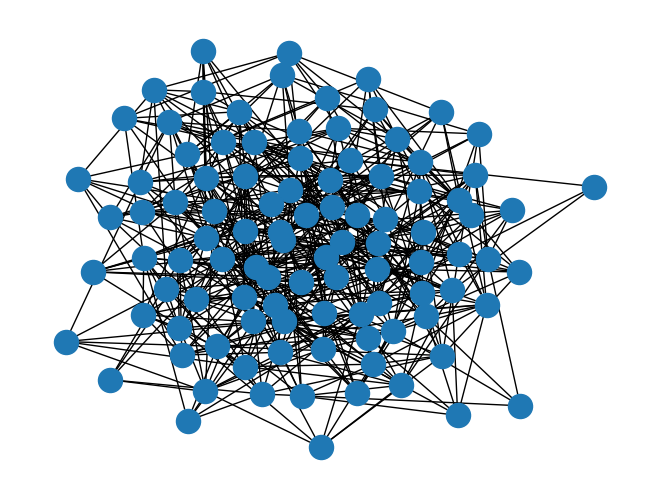

In [22]:
mpl_draw(rx.undirected_gnp_random_graph(100, 0.1, seed=42))

In [23]:
num_nodes = 1000 # Number of nodes in graph
graph = rx.undirected_gnp_random_graph(num_nodes, 0.1, seed=42)

In [24]:
import networkx as nx
 
nx_graph = nx.Graph()
nx_graph.add_nodes_from(range(num_nodes))

In [25]:
for edge in graph.edge_list():
    nx_graph.add_edge(edge[0], edge[1])

In [26]:
curr_cut_size, partition = nx.approximation.one_exchange(nx_graph, seed=1)
print(f"Initial cut size: {curr_cut_size}")

Initial cut size: 28075


In [27]:
num_qubits = 100
 
list_size = num_nodes // 3
node_x = [i for i in range(list_size)]
node_y = [i for i in range(list_size, 2 * list_size)]
node_z = [i for i in range(2 * list_size, num_nodes)]
 
print("List 1:", node_x)
print("List 2:", node_y)
print("List 3:", node_z)

List 1: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 2

In [28]:
def build_pauli_correlation_encoding(pauli, node_list, n, k=2):
    pauli_correlation_encoding = []
    for idx, c in enumerate(combinations(range(n), k)):
        if idx >= len(node_list):
            break
        paulis = ["I"] * n
        paulis[c[0]], paulis[c[1]] = pauli, pauli
        pauli_correlation_encoding.append(("".join(paulis)[::-1], 1))
 
    hamiltonian = []
    for pauli, weight in pauli_correlation_encoding:
        hamiltonian.append(SparsePauliOp.from_list([(pauli, weight)]))
 
    return hamiltonian
 
 
pauli_correlation_encoding_x = build_pauli_correlation_encoding(
    "X", node_x, num_qubits
)
pauli_correlation_encoding_y = build_pauli_correlation_encoding(
    "Y", node_y, num_qubits
)
pauli_correlation_encoding_z = build_pauli_correlation_encoding(
    "Z", node_z, num_qubits
)

Step 2: Optimize problem for quantum hardware execution

In [29]:
# Build the quantum circuit
qc = efficient_su2(num_qubits, ["ry", "rz"], reps=2)

# Optimize the circuit
 
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc = pm.run(qc)

In [30]:
def loss_func_estimator(x, ansatz, hamiltonian, estimator, graph):
    """
    Calculates the specified loss function for the given ansatz, Hamiltonian, and graph.
 
    The expectation values of each Pauli string in the Hamiltonian are first obtained
    by running the ansatz on the quantum backend. These expectation values are then
    passed through the nonlinear function tanh(alpha * prod_i). The loss function is
    subsequently computed from these transformed values.
    """
    job = estimator.run(
        [
            (ansatz, hamiltonian[0], x),
            (ansatz, hamiltonian[1], x),
            (ansatz, hamiltonian[2], x),
        ]
    )
    result = job.result()
 
    # calculate the loss function
    node_exp_map = {}
    idx = 0
    for r in result:
        for ev in r.data.evs:
            node_exp_map[idx] = ev
            idx += 1
 
    loss = 0
    alpha = num_qubits
    for edge0, edge1 in graph.edge_list():
        loss += np.tanh(alpha * node_exp_map[edge0]) * np.tanh(
            alpha * node_exp_map[edge1]
        )
 
    regulation_term = 0
    for i in range(len(graph.nodes())):
        regulation_term += np.tanh(alpha * node_exp_map[i]) ** 2
    regulation_term = regulation_term / len(graph.nodes())
    regulation_term = regulation_term**2
    beta = 1 / 2
    v = len(graph.edges()) / 2 + (len(graph.nodes()) - 1) / 4
    regulation_term = beta * v * regulation_term
 
    loss = loss + regulation_term
 
    global experiment_result
    print(f"Iter {len(experiment_result)}: {loss}")
    experiment_result.append({"loss": loss, "exp_map": node_exp_map})
    return loss

Step 3: Execute using Qiskit primitives

In [31]:
pce = []
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_x]
)
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_y]
)
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_z]
)

In [32]:
# Run the optimization using Session
 
with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
 
    experiment_result = []
 
    def loss_func(x):
        return loss_func_estimator(
            x, qc, [pce[0], pce[1], pce[2]], estimator, graph
        )
 
    np.random.seed(42)
    initial_params = np.random.rand(qc.num_parameters)
    result = minimize(
        loss_func, initial_params, method="COBYLA", options={"maxiter": 50}
    )
print(result)

TypeError: EstimatorV2.__init__() got an unexpected keyword argument 'mode'

Step 4: Post-process and return result in desired classical format

In [ ]:
# Calculate the partitions based on the final expectation values
# If the expectation value is positive, the node belongs to partition 0 (par0)
# Otherwise, the node belongs to partition 1 (par1)
 
par0, par1 = set(), set()
 
for i in experiment_result[-1]["exp_map"]:
    if experiment_result[-1]["exp_map"][i] >= 0:
        par0.add(i)
    else:
        par1.add(i)
print(par0, par1)

In [ ]:
cut_size = calc_cut_size(graph, par0, par1)
print(f"Cut size: {cut_size}")

In [ ]:
best_bits = []
cur_bits = []
 
for i in experiment_result[-1]["exp_map"]:
    if experiment_result[-1]["exp_map"][i] >= 0:
        cur_bits.append(1)
    else:
        cur_bits.append(0)
print(cur_bits)

In [ ]:
# Swap the partitions and calculate the cut size
best_cut = 0
for edge0, edge1 in graph.edge_list():
    swapped_bits = cur_bits.copy()
    swapped_bits[edge0], swapped_bits[edge1] = (
        swapped_bits[edge1],
        swapped_bits[edge0],
    )
 
    cur_partition = [set(), set()]
    for i, bit in enumerate(swapped_bits):
        if bit > 0:
            cur_partition[0].add(i)
        else:
            cur_partition[1].add(i)
    cut_size = calc_cut_size(graph, cur_partition[0], cur_partition[1])
    if best_cut < cut_size:
        best_cut = cut_size
        best_bits = swapped_bits
 
print(best_cut, best_bits)